# Gallstone Prediction using ML Models

In [11]:
# Core libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

# Logistic Regression tools
from Logistic_bootstrap_metrics import bootstrap_metrics, plot_roc_curve, build_summary_table, plot_bootstrapped_roc_curve

# Machine Learning Tools
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve, 
    auc
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## Load and Prepare Data

In [12]:
# Load data set
df = pd.read_csv("data/gallstone_data_train_test_split.csv")

# Split into train and test based on 'Set' column
df_train = df[df['Set'] == 'train']
df_test = df[df['Set'] == 'test']

## Logistic Regression on a Single Features with Bootstrapping

Using class weighting automatically.
Best Threshold found automatically: 0.43


/Users/lisan/Library/Python/3.14/lib/python/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: weights. After release 0.14, this will raise.
  warnings.warn(



===== Odds Ratios (one-time fit) — Gender =====
        Odds Ratio  95% CI Lower  95% CI Upper   p-value
const     0.753425      0.530954      1.069111  0.112810
Gender    1.682792      1.025631      2.761022  0.039385

===== Bootstrapped Metrics (1000 runs) - Gender =====
AUC: Mean = 0.6259, 95% CI = [0.5925, 0.6615]
Balanced Accuracy: Mean = 0.6259, 95% CI = [0.5925, 0.6615]
Sensitivity: Mean = 0.5947, 95% CI = [0.5517, 0.6552]
Specificity: Mean = 0.6570, 95% CI = [0.6207, 0.7000]
Precision: Mean = 0.6341, 95% CI = [0.5926, 0.6786]
F1-score: Mean = 0.6135, 95% CI = [0.5714, 0.6552]


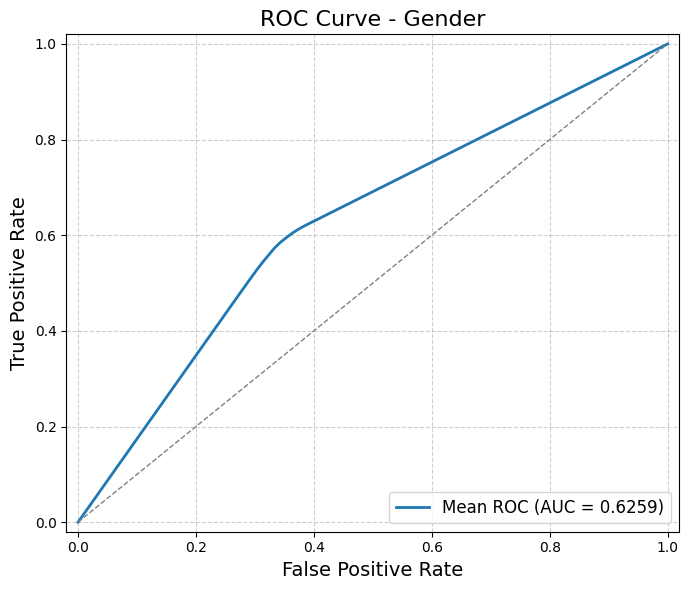

In [19]:
# Define a gender feature and target
gender_feature = 'Gender'
target = 'Gallstone Status'

# Separate features and target for train and test sets
X_train = df_train[[gender_feature]]
y_train = df_train[target]
X_test = df_test[[gender_feature]]
y_test = df_test[target]

# Logistic Regression on Gender Feature with Bootstrapping
gender_model = bootstrap_metrics(
    df_train=X_train,
    df_test=X_test,
    independent_vars=['Gender'],
    dep_var_train=y_train,
    dep_var_test=y_test,
    n_bootstrap=1000,
)

# Display results
print("\n===== Odds Ratios (one-time fit) — Gender =====")
print(gender_model["Odds Ratios (one-time fit)"])

print("\n===== Bootstrapped Metrics (1000 runs) - Gender =====")
for metric, (mean, ci) in gender_model["Bootstrapped Metrics"].items():
    print(f"{metric}: Mean = {mean:.4f}, 95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")


plot_bootstrapped_roc_curve(
    gender_model["Bootstrapped ROC Curve"],
    title="ROC Curve - Gender"
)